# Retinopatia Diabética

Datasets analisados:

- Aptos-2019
- EyePACS
- IDRiD
- Messidor-2

## Configuração de ambiente

In [34]:
from pathlib import Path
import unicodedata

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def normalize_name(value):
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(ch for ch in value if not unicodedata.combining(ch)).casefold()

def first_existing_path(*paths):
    for path in paths:
        if path.exists():
            return path
    return paths[0]

def find_project_root(start_dir=None):
    start_dir = (start_dir or Path.cwd()).resolve()
    candidates = [start_dir, *start_dir.parents]

    for candidate in candidates:
        if not candidate.exists():
            continue

        if (candidate / "01.Originais").exists() and (candidate / "02.Catálogos").exists():
            return candidate

        for child in candidate.iterdir():
            if child.is_dir():
                if (child / "01.Originais").exists() and (child / "02.Catálogos").exists():
                    return child

    return start_dir

BASE_DIR = find_project_root()

EYEPACS_METADATA = first_existing_path(
    BASE_DIR / "02.Catálogos" / "METADADOS" / "Treino" / "eyepacs_metadata.csv",
    BASE_DIR / "02.Catálogos" / "METADADOS" / "treino" / "eyepacs_metadata.csv",
    BASE_DIR / "02.Catálogos" / "METADADOS" / "eyepacs_metadata.csv",
)

print(EYEPACS_METADATA)
print("Existe:", EYEPACS_METADATA.exists())

C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Treino\eyepacs_metadata.csv
Existe: True


## 1. Aptos-2019

### 1.1 Conjunto de treino.

In [35]:
# Localizando o arquivo de metadados de treino do APTOS.
APTOS_METADATA = (
    BASE_DIR
    / "02.Catálogos"
    / "METADADOS"
    / "Treino"
    / "aptos_metadata.csv"
)

print(APTOS_METADATA)
print("Existe:", APTOS_METADATA.exists())

C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Treino\aptos_metadata.csv
Existe: True


In [36]:
# Cria um dataframe a partir do arquivo CSV de metadados do APTOS.
aptos = pd.read_csv(APTOS_METADATA)

# Mostra as primeiras linhas do dataframe.
aptos.head()

,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,APTOS_2019,000c1434d8d7.png,retinopatia_diabetica,2,retinopatia_diabetica_moderada,train
1,2,APTOS_2019,001639a390f0.png,retinopatia_diabetica,4,retinopatia_diabetica_proliferativa,train
2,3,APTOS_2019,0024cdab0c1e.png,retinopatia_diabetica,1,retinopatia_diabetica_leve,train
3,4,APTOS_2019,002c21358ce6.png,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
4,5,APTOS_2019,005b95c28852.png,retinopatia_diabetica,0,sem_retinopatia_diabetica,train


In [37]:
# Mostra informações sobre o dataframe.
aptos.columns.tolist()

['id_imagem',
 'dataset',
 'arquivo',
 'doenca',
 'codigo_diagnostico',
 'diagnostico',
 'conjunto']

#### 1.1.1 Estrutura geral do conjunto de treino.

In [38]:
print("Quantidade de registros:", len(aptos))
print("Quantidade de colunas:", len(aptos.columns))
print("Dimensão da tabela:", aptos.shape)

Quantidade de registros: 3662
Quantidade de colunas: 7
Dimensão da tabela: (3662, 7)


In [39]:
# Mostra a forma como a tabela está estruturada.
aptos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_imagem           3662 non-null   int64
 1   dataset             3662 non-null   str  
 2   arquivo             3662 non-null   str  
 3   doenca              3662 non-null   str  
 4   codigo_diagnostico  3662 non-null   int64
 5   diagnostico         3662 non-null   str  
 6   conjunto            3662 non-null   str  
dtypes: int64(2), str(5)
memory usage: 200.4 KB


In [40]:
# Verifica se há valores nulos no dataframe.
aptos.isnull().sum()

id_imagem             0
dataset               0
arquivo               0
doenca                0
codigo_diagnostico    0
diagnostico           0
conjunto              0
dtype: int64

#### 1.1.2 Verificação de duplicatas e consistência dos registros.

In [41]:
# Verifica se há linhas duplicadas no conjunto de treino.
print("Linhas duplicadas:", aptos.duplicated().sum())
print("IDs duplicados:", aptos["id_imagem"].duplicated().sum())
print("Arquivos duplicados:", aptos["arquivo"].duplicated().sum())

Linhas duplicadas: 0
IDs duplicados: 0
Arquivos duplicados: 0


In [42]:
print("Valores da coluna dataset:") 
print(aptos["dataset"].value_counts())

print("\nValores da coluna doença:")
print(aptos["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(aptos["conjunto"].value_counts())

Valores da coluna dataset:
dataset
APTOS_2019    3662
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    3662
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
train    3662
Name: count, dtype: int64


#### 1.1.3 Distribuição das classes.

In [43]:
# Mostra os códigos de diagnóstico e seus respectivos diagnósticos.
aptos[["codigo_diagnostico", "diagnostico"]].drop_duplicates().sort_values("codigo_diagnostico")

,codigo_diagnostico,diagnostico
3,0,sem_retinopatia_diabetica
2,1,retinopatia_diabetica_leve
0,2,retinopatia_diabetica_moderada
13,3,retinopatia_diabetica_grave
1,4,retinopatia_diabetica_proliferativa


In [44]:
# Checa a distribuição dos códigos de diagnóstico.
distribuicao = (
    aptos["codigo_diagnostico"].value_counts().sort_index()
)

distribuicao

codigo_diagnostico
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

In [45]:
percentual = (
    aptos["codigo_diagnostico"].value_counts(normalize=True).sort_index() * 100
)

percentual.round(2)

codigo_diagnostico
0    49.29
1    10.10
2    27.28
3     5.27
4     8.06
Name: proportion, dtype: float64

In [46]:
tabela_classes = pd.DataFrame({
    "Quantidade": distribuicao,
    "Percentual": percentual.round(2)
})

tabela_classes

,Quantidade,Percentual
codigo_diagnostico,,
0,1805,49.29
1,370,10.10
2,999,27.28
3,193,5.27
4,295,8.06


#### Interpretação

O APTOS-2019 apresenta forte desbalanceamento entre as classes:

- Grau 0 - Sem retinopatia diabética: 1805 imagens (49,29%)
- Grau 1 - Retinopatia diabética leve: 370 imagens (10,10%)
- Grau 2 - Retinopatia diabética moderada: 999 imagens (27,28%)
- Grau 3 - Retinopatia diabética grave: 193 imagens (5,27%)
- Grau 4 - Retinopatia diabética proliferativa: 295 imagens (8,06%)

Sendo assim, a classe mais frequente é grau 0 (Sem retinopatia), enquanto a classe 3 (Retinopatia grave) possui menor participação no dataset.

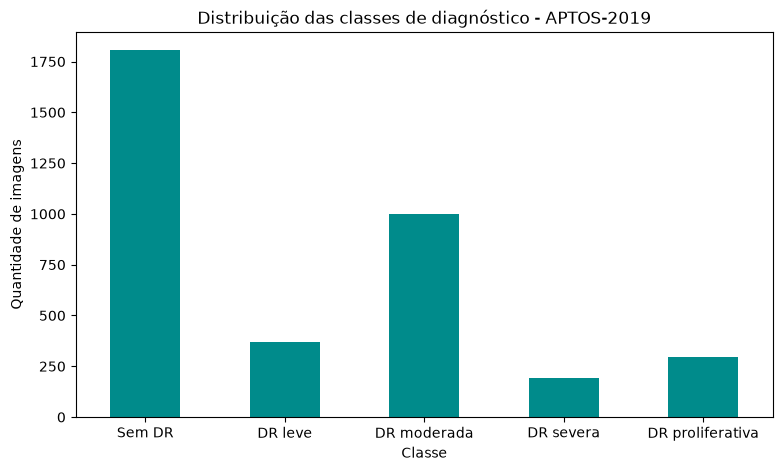

In [47]:
# Cria um gráfico para mostrar a distribuição das classes de diagnóstico com seus respectivos nomes.
nomes_classes = {
    0: "Sem DR",
    1: "DR leve",
    2: "DR moderada",
    3: "DR severa",
    4: "DR proliferativa"
}

quantidades = distribuicao.copy()
quantidades.index = quantidades.index.map(nomes_classes)

quantidades.plot(kind="bar", figsize=(9, 5), color="darkcyan")

plt.title("Distribuição das classes de diagnóstico - APTOS-2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=0)
plt.show()

#### 1.1.4 Correspondência entre metadata e imagens.

In [48]:
# Verifica se a pasta do APTOS existe.
APTOS_DIR = (
    BASE_DIR
    / "01.Originais"
    / "DR (RETINOPATIA DIABÉTICA)"
    / "APTOS-2019"
)

print("Pasta do APTOS:", APTOS_DIR)
print("Existe:", APTOS_DIR.exists())

Pasta do APTOS: C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\01.Originais\DR (RETINOPATIA DIABÉTICA)\APTOS-2019
Existe: True


In [143]:
# Localiza todas as imagens PNG na pasta do APTOS.
APTOS_TRAIN_IMAGES_DIR = APTOS_DIR / "train_images"

imagens_aptos_train = list(APTOS_TRAIN_IMAGES_DIR.glob("*.png"))

print("Quantidade de imagens de treino:", len(imagens_aptos_train))
print("Quantidade de registros no metadados:", len(aptos))

Quantidade de imagens de treino: 3662
Quantidade de registros no metadados: 3662


In [144]:
# Compara os arquivos de imagens de treino com os registros do metadados.
arquivos_metadata_train = set(aptos["arquivo"])
arquivos_imagens_train = set([imagem.name for imagem in imagens_aptos_train])

sem_imagem_train = arquivos_metadata_train - arquivos_imagens_train
sem_metadata_train = arquivos_imagens_train - arquivos_metadata_train

print("Arquivos no metadados sem imagem correspondente:", len(sem_imagem_train))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata_train))

Arquivos no metadados sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 1.1.5 Análise técnica das imagens de treino.

In [145]:
# Analisa uma imagem de treino para verificar seu formato e modo de cor.
from PIL import Image

imagem_exemplo_aptos = imagens_aptos_train[0]

with Image.open(imagem_exemplo_aptos) as img:
    print("Arquivo:", imagem_exemplo_aptos.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 000c1434d8d7.png
Formato: PNG
Modo de cor: RGB
Resolução: (3216, 2136)


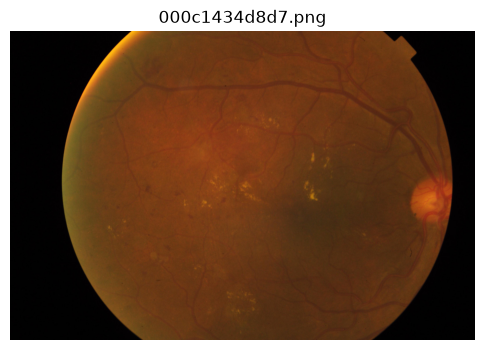

In [146]:
# Mostra a imagem de exemplo.
with Image.open(imagem_exemplo_aptos) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo_aptos.name)
    plt.show()

In [53]:
# Função para analisar tecnicamente o conjunto de imagens.
def analisar_imagens(lista_imagens):
    registros = []
    erros = []

    for caminho in lista_imagens:
        try:
            with Image.open(caminho) as img:

                # Força a leitura da imagem inteira.
                img.load()

                registros.append({
                    "arquivo": caminho.name,
                    "formato": img.format,
                    "modo_cor": img.mode,
                    "largura": img.width,
                    "altura": img.height,
                    "resolucao": f"{img.width}x{img.height}",
                    "tamanho_mb": caminho.stat().st_size / (1024 ** 2)
                })

        except Exception as erro:
            erros.append({
                "arquivo": caminho.name,
                "erro": str(erro)
            })

    dados = pd.DataFrame(registros)
    erros = pd.DataFrame(erros)

    return dados, erros

In [152]:
# Analisa todas as imagens de treino.
analise_aptos_train, erros_aptos_train = analisar_imagens(imagens_aptos_train)

print("Imagens analisadas:", len(analise_aptos_train))
print("Erros de leitura:", len(erros_aptos_train))

analise_aptos_train.head()

Imagens analisadas: 3662
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,000c1434d8d7.png,PNG,RGB,3216,2136,3216x2136,3.069569
1,001639a390f0.png,PNG,RGB,3216,2136,3216x2136,2.156381
2,0024cdab0c1e.png,PNG,RGB,2416,1736,2416x1736,1.794979
3,002c21358ce6.png,PNG,RGB,1050,1050,1050x1050,0.930040
4,005b95c28852.png,PNG,RGB,2048,1536,2048x1536,1.735144


In [ ]:
# Mostra formatos e modos de cor encontrados nas imagens de treino.
print("Fomatos encontrados:")
print(analise_aptos_train["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_aptos_train["modo_cor"].value_counts())

Fomatos encontrados:
formato
PNG    3662
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    3662
Name: count, dtype: int64


In [ ]:
print("Quantidade de resoluções diferentes:")
print(analise_aptos_train["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_aptos_train["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
17

10 resoluções mais frequentes:
resolucao
1050x1050    974
2416x1736    638
2588x1958    533
3216x2136    410
2048x1536    351
819x614      287
3388x2588    141
1504x1000     92
1844x1226     61
4288x2848     52
Name: count, dtype: int64


In [156]:
print("Estatísticas da largura:")
print(analise_aptos_train["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_aptos_train["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_aptos_train["tamanho_mb"].describe())

Estatísticas da largura:
count    3662.000000
mean     2015.176679
std       884.301940
min       474.000000
25%      1050.000000
50%      2144.000000
75%      2588.000000
max      4288.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    3662.000000
mean     1526.830147
std       542.663120
min       358.000000
25%      1050.000000
50%      1536.000000
75%      1958.000000
max      2848.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    3662.000000
mean        2.240448
std         1.680805
min         0.211465
25%         0.957485
50%         1.845313
75%         2.714966
max         7.318775
Name: tamanho_mb, dtype: float64


##### Interpretação

As 3.662 imagens do conjunto de treino foram lidas com sucesso, sem erros.

Todas as imagens estão no formato PNG e utilizam o modo de cor RGB.

Foram identificadas 17 resoluções diferentes, mostrando que o conjunto não possui dimensões padronizadas. A resolução mais frequente é 1050x1050, que corresponde há 974 imagens.

A largura das imagens varia de 474 a 4288 pixels, enquanto a altura varia de 358 a 2848 pixels. O tamanho dos arquivos varia aproximadamente entre 0,21 MB e 7,32 MB.

Essas diferenças de dimensão indicam heterogeneidade na resolução das imagens e devem ser consideradas em eventuais etapas futuras de pré-processamento.

#### 1.1.6 Qualidade e duplicatas das imagens.

In [165]:
# Função para calcular o hash SHA-256 de um arquivo.
import hashlib

def calcular_hash(caminho):
    sha256 = hashlib.sha256()

    with open(caminho, "rb") as arquivo:
        for bloco in iter(lambda: arquivo.read(8192), b""):
            sha256.update(bloco)

    return sha256.hexdigest()

In [166]:
# Cria um dataframe com os hashes das imagens de treino.
hashes_aptos_train = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_aptos_train],
    "hash": [calcular_hash(imagem) for imagem in imagens_aptos_train]
})

hashes_aptos_train.head()

,arquivo,hash
0,000c1434d8d7.png,3f34b577a7102dddea20d2aaed76028bcf724ddb82e923...
1,001639a390f0.png,9e4a10bcf0569bd7640ff3107601cb00c1147c44de5d3e...
2,0024cdab0c1e.png,ef0bda2c21f3dbe839b4e5168fa7e52afe61e6923a56fd...
3,002c21358ce6.png,c18a236541ae3d3ddbf8cf3eae991b4ff28446c5313b3d...
4,005b95c28852.png,4af20410946f8730d1a9c13361a0b4604c5934c325890b...


In [171]:
# Identifica imagens duplicadas em treino com base no hash.
duplicados_aptos_train = hashes_aptos_train[
    hashes_aptos_train["hash"].duplicated(keep=False)
].sort_values("hash")

print("Imagens pertencentes a grupos duplicados:", len(duplicados_aptos_train))
print("Hashes duplicados:", duplicados_aptos_train["hash"].nunique())

Imagens pertencentes a grupos duplicados: 251
Hashes duplicados: 123


In [252]:
# Relaciona os hashes das imagens aos diagnósticos do conjunto de treino.

hashes_train_diagnostico_aptos = hashes_aptos_train.merge(
    aptos[["arquivo", "codigo_diagnostico", "diagnostico"]],
    on="arquivo",
    how="left"
)

# Conta quantos diagnósticos diferentes existem para cada hash.

diagnosticos_por_hash_aptos = (
    hashes_train_diagnostico_aptos
    .groupby("hash")["codigo_diagnostico"]
    .nunique()
)

# Seleciona hashes associados a diagnósticos diferentes.

grupos_conflitantes_aptos = diagnosticos_por_hash_aptos[
    diagnosticos_por_hash_aptos > 1
]

# Identifica todas as imagens desses grupos.

imagens_conflitantes_aptos = hashes_train_diagnostico_aptos[
    hashes_train_diagnostico_aptos["hash"].isin(grupos_conflitantes_aptos.index)
]

print("Grupos conflitantes:", len(grupos_conflitantes_aptos))
print("Imagens envolvidas:", len(imagens_conflitantes_aptos))

Grupos conflitantes: 30
Imagens envolvidas: 62


##### Exemplo de conflito de diagnóstico em imagens duplicadas

In [181]:
# Seleciona um hash que possui diagnósticos conflitantes.

hash_exemplo_aptos = grupos_conflitantes_aptos.index[0]

exemplo_conflitante_aptos = (
    hashes_train_diagnostico_aptos[
        hashes_train_diagnostico_aptos["hash"] == hash_exemplo_aptos
    ]
    .head(2)
)

exemplo_conflitante_aptos[
    ["arquivo", "codigo_diagnostico", "diagnostico", "hash"]
]

,arquivo,codigo_diagnostico,diagnostico,hash
145,0ac436400db4.png,2,retinopatia_diabetica_moderada,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...
3627,fda39982a810.png,3,retinopatia_diabetica_grave,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...


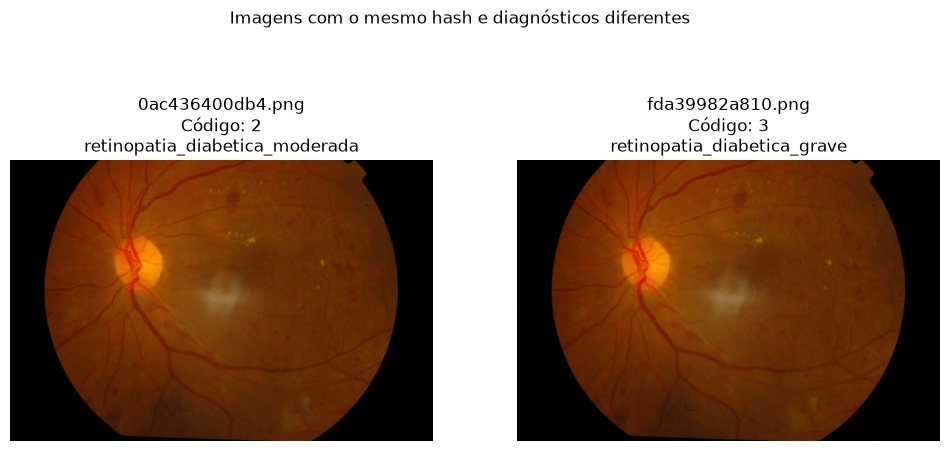

In [182]:
fig_aptos, axes_aptos = plt.subplots(1, 2, figsize=(12, 6))

for ax, (_, linha) in zip(axes_aptos, exemplo_conflitante_aptos.iterrows()):
    caminho = APTOS_DIR / "train_images" / linha["arquivo"]

    with Image.open(caminho) as img:
        ax.imshow(img)

    ax.set_title(
        f'{linha["arquivo"]}\n'
        f'Código: {linha["codigo_diagnostico"]}\n'
        f'{linha["diagnostico"]}'
    )

    ax.axis("off")

plt.suptitle("Imagens com o mesmo hash e diagnósticos diferentes")
plt.show()

##### Interpretação

Foram identificados 123 grupos de imagens duplicadas no conjunto de treino, envolvendo 251 arquivos.

Entre esses grupos, 30 apresentam conflito de diagnóstico, totalizando 62 imagens com conteúdo idêntico associado a classificações diferentes.

O exemplo apresentado acima demonstra visualmente esse problema: duas imagens com o mesmo hash SHA-256, portanto com conteúdo idêntico, possuem diagnósticos distintos. Esse tipo de inconsistência deve ser considerado antes da utilização do dataset em experimentos de aprendizado de máquina.

### 1.2 Conjunto de teste.

#### 1.2.1 Estrutura geral do conjunto de teste

In [62]:
# Localizando o arquivo de metadados de teste do APTOS.
APTOS_TEST_METADATA = (
    BASE_DIR
    / "02.Catálogos"
    / "METADADOS"
    / "Teste"
    / "aptos_test_metadata.csv"
)

print(APTOS_TEST_METADATA)
print("Existe:", APTOS_TEST_METADATA.exists())

C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Teste\aptos_test_metadata.csv
Existe: True


In [63]:
# Cria o dataframe de a partir dos metadados de teste do APTOS.
aptos_test = pd.read_csv(APTOS_TEST_METADATA)

aptos_test.head()

,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,APTOS_2019,0005cfc8afb6.png,retinopatia_diabetica,NaN,nao_disponivel,test
1,2,APTOS_2019,003f0afdcd15.png,retinopatia_diabetica,NaN,nao_disponivel,test
2,3,APTOS_2019,006efc72b638.png,retinopatia_diabetica,NaN,nao_disponivel,test
3,4,APTOS_2019,00836aaacf06.png,retinopatia_diabetica,NaN,nao_disponivel,test
4,5,APTOS_2019,009245722fa4.png,retinopatia_diabetica,NaN,nao_disponivel,test


In [64]:
print("Quantidade de registros:", len(aptos_test))
print("Quantidade de colunas:", len(aptos_test.columns))
print("Dimensão da tabela:", aptos_test.shape)

Quantidade de registros: 1928
Quantidade de colunas: 7
Dimensão da tabela: (1928, 7)


In [65]:
# Mostra a estrutura do dataframe de teste.
aptos_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1928 entries, 0 to 1927
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_imagem           1928 non-null   int64  
 1   dataset             1928 non-null   str    
 2   arquivo             1928 non-null   str    
 3   doenca              1928 non-null   str    
 4   codigo_diagnostico  0 non-null      float64
 5   diagnostico         1928 non-null   str    
 6   conjunto            1928 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 105.6 KB


In [66]:
# Verifica valores ausentes no conjunto de teste.
aptos_test.isnull().sum()

id_imagem                0
dataset                  0
arquivo                  0
doenca                   0
codigo_diagnostico    1928
diagnostico              0
conjunto                 0
dtype: int64

#### 1.2.2 Verificação de duplicatas e consistência dos registros.

In [67]:
# Checa se há linhas duplicadas no conjunto de teste.
print("Linhas duplicadas no conjunto de teste:", aptos_test.duplicated().sum())
print("IDs duplicados no conjunto de teste:", aptos_test["id_imagem"].duplicated().sum())
print("Arquivos duplicados no conjunto de teste:", aptos_test["arquivo"].duplicated().sum())

Linhas duplicadas no conjunto de teste: 0
IDs duplicados no conjunto de teste: 0
Arquivos duplicados no conjunto de teste: 0


In [68]:
print("Valores da coluna dataset:")
print(aptos_test["dataset"].value_counts())

print("\nValores da coluna doença:")
print(aptos_test["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(aptos_test["conjunto"].value_counts())

print("\nCódigos de diagnóstico ausentes:")
print(aptos_test["codigo_diagnostico"].isna().sum())

Valores da coluna dataset:
dataset
APTOS_2019    1928
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    1928
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
test    1928
Name: count, dtype: int64

Códigos de diagnóstico ausentes:
1928


#### 1.2.3 Disponibilidade dos diagnósticos.

In [69]:
# Verifica a disponibilidade dos diagnósticos no conjunto de teste.

print(
    "Códigos de diagnóstico ausentes:",
    aptos_test["codigo_diagnostico"].isna().sum()
)

print("\nValores da coluna diagnóstico:")
print(
    aptos_test["diagnostico"].value_counts(dropna=False)
)

Códigos de diagnóstico ausentes: 1928

Valores da coluna diagnóstico:
diagnostico
nao_disponivel    1928
Name: count, dtype: int64


O conjunto de teste do APTOS-2019 não possui os diagnósticos reais disponíveis nos arquivos utilizados nesta análise. Por esse motivo, não é possível realizar a distribuição das classes para o conjunto de teste.

#### 1.2.4 Correspondência entre metadata e imagens.

In [214]:
# Localiza a pasta de imagens de teste.

TESTE_APTOS_IMAGES_DIR = APTOS_DIR / "test_images"

imagens_aptos_test = list(TESTE_APTOS_IMAGES_DIR.glob("*.png"))

print("Quantidade de imagens de teste:", len(imagens_aptos_test))
print("Quantidade de registros no metadados:", len(aptos_test))

Quantidade de imagens de teste: 1928
Quantidade de registros no metadados: 1928


In [211]:
# Compara os arquivos de imagens de teste com os registros do metadados.
arquivos_sem_metadata_aptos = set(aptos_test["arquivo"])
arquivos_sem_imagem_aptos = set([imagem.name for imagem in imagens_aptos_test])

sem_imagem_aptos = arquivos_sem_metadata_aptos - arquivos_sem_imagem_aptos
sem_metadata_aptos = arquivos_sem_imagem_aptos - arquivos_sem_metadata_aptos

print("Arquivos no metadados sem imagem correspondente:", len(sem_imagem_aptos))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata_aptos))

Arquivos no metadados sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 1.2.5 Análise técnica das imagens de teste.

In [217]:
# Analisa uma imagem de teste para verificar seu formato e modo de cor.
imagem_exemplo_aptos_test = imagens_aptos_test[0]

with Image.open(imagem_exemplo_aptos_test) as img:
    print("Arquivo:", imagem_exemplo_aptos_test.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 0005cfc8afb6.png
Formato: PNG
Modo de cor: RGB
Resolução: (640, 480)


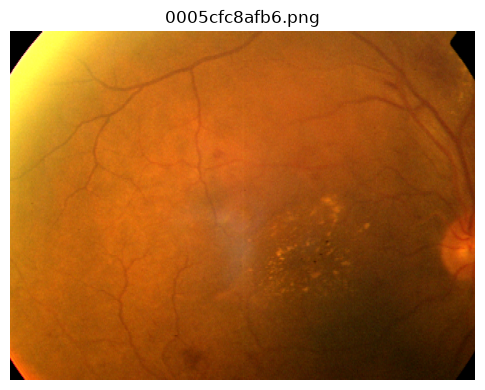

In [219]:
# Mostra a imagem de teste.
with Image.open(imagem_exemplo_aptos_test) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo_aptos_test.name)
    plt.show()

In [249]:
# Reutiliza a função de análise para o conjunto de imagens de teste.
analise_aptos_test, erros_aptos_test = analisar_imagens(imagens_aptos_test)

print("Imagens analisadas:", len(analise_aptos_test))
print("Erros de leitura:", len(erros_aptos_test))

analise_aptos_test.head()

Imagens analisadas: 1928
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,0005cfc8afb6.png,PNG,RGB,640,480,640x480,0.225072
1,003f0afdcd15.png,PNG,RGB,640,480,640x480,0.202460
2,006efc72b638.png,PNG,RGB,640,480,640x480,0.193110
3,00836aaacf06.png,PNG,RGB,640,480,640x480,0.223653
4,009245722fa4.png,PNG,RGB,640,480,640x480,0.235420


In [ ]:
# Mostra formatos e modos de cor encontrados nas imagens de teste.
print("Formatos encontrados:")
print(analise_aptos_test["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_aptos_test["modo_cor"].value_counts())

Formatos encontrados:
formato
PNG    1928
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    1928
Name: count, dtype: int64


In [ ]:
# Mostra estatísticas das resoluções encontradas nas imagens de teste.
print("Quantidade de resoluções diferentes:")
print(analise_aptos_test["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_aptos_test["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
12

10 resoluções mais frequentes:
resolucao
640x480      1403
2416x1736     225
2588x1958     134
1050x1050      69
819x614        45
2048x1536      28
2896x1944      11
2592x1944       6
768x576         2
1467x1110       2
Name: count, dtype: int64


In [ ]:
print("Estatísticas da largura:")
print(analise_aptos_test["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_aptos_test["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_aptos_test["tamanho_mb"].describe())

Estatísticas da largura:
count    1928.000000
mean     1043.535788
std       740.511732
min       640.000000
25%       640.000000
50%       640.000000
75%       819.000000
max      2896.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    1928.000000
mean      783.152490
std       541.308109
min       480.000000
25%       480.000000
50%       480.000000
75%       614.000000
max      1958.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    1928.000000
mean        0.798230
std         1.231747
min         0.174269
25%         0.209105
50%         0.219121
75%         0.408817
max         5.541361
Name: tamanho_mb, dtype: float64


##### Interpretação

As 1.928 imagens do conjunto de teste foram lidas com sucesso, sem erros.

Todas as imagens estão no formato PNG e utilizam o modo de cor RGB.

Foram identificadas 12 resoluções diferentes. A resolução predominante é 640x480, presente em 1.403 imagens, correspondendo à maior parte do conjunto de teste.

A largura das imagens varia de 640 a 2896 pixels, enquanto a altura varia de 480 a 1958 pixels. O tamanho médio dos arquivos é de aproximadamente 0,80 MB.

Assim como no conjunto de treino, existem diferentes resoluções no conjunto de teste. Entretanto, o teste apresenta forte predominância de imagens com resolução 640x480.

#### 1.2.6 Qualidade e duplicatas das imagens.

In [233]:
# Cria um dataframe com os hashes das imagens de teste do APTOS.

hashes_aptos_test = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_aptos_test],
    "hash": [calcular_hash(imagem) for imagem in imagens_aptos_test]
})

hashes_aptos_test.head()

,arquivo,hash
0,0005cfc8afb6.png,e001c14dcb9c61b90d1fe48f72c2ca86b333c426902d68...
1,003f0afdcd15.png,7a2788507137cdfffe20f42903fa755db13c87fbf48645...
2,006efc72b638.png,5f82049508338b1e86adea0991c314614ea96e213505d9...
3,00836aaacf06.png,84e34dbfc3cb7e028401b308c1cbeabfa55beb82313c65...
4,009245722fa4.png,e38547568df0c3c2480e5168fb4ba9cbe4bf9e9f7a105e...


In [235]:
# Identifica imagens duplicadas no teste com base no hash.

duplicados_aptos_test = hashes_aptos_test[
    hashes_aptos_test["hash"].duplicated(keep=False)
].sort_values("hash")

print(
    "Imagens pertencentes a grupos duplicados:",
    len(duplicados_aptos_test)
)

print(
    "Hashes duplicados:",
    duplicados_aptos_test["hash"].nunique()
)

Imagens pertencentes a grupos duplicados: 12
Hashes duplicados: 6


### 1.3 Comparação entre treino e teste

#### 1.3.1 Duplicatas entre os conjuntos

In [236]:
# Identifica hashes presentes tanto no conjunto de treino quanto no conjunto de teste.

hashes_compartilhados_aptos = (
    set(hashes_aptos_train["hash"])
    & set(hashes_aptos_test["hash"])
)

print(
    "Hashes compartilhados entre treino e teste:",
    len(hashes_compartilhados_aptos)
)

Hashes compartilhados entre treino e teste: 140


In [239]:
# Localiza as imagens de treino e teste que possuem
# hashes presentes nos dois conjuntos.

imagens_train_aptos_compartilhadas = hashes_aptos_train[
    hashes_aptos_train["hash"].isin(hashes_compartilhados_aptos)
]

imagens_test_aptos_compartilhadas = hashes_aptos_test[
    hashes_aptos_test["hash"].isin(hashes_compartilhados_aptos)
]

print(
    "Imagens de treino envolvidas:",
    len(imagens_train_aptos_compartilhadas)
)

print(
    "Imagens de teste envolvidas:",
    len(imagens_test_aptos_compartilhadas)
)

Imagens de treino envolvidas: 150
Imagens de teste envolvidas: 141


In [ ]:
# Verifica quais hashes compartilhados entre treino e teste também pertencem a grupos conflitantes no treino.

hashes_compartilhados_conflitantes_aptos = (
    hashes_compartilhados_aptos
    & set(grupos_conflitantes_aptos.index)
)

print(
    "Hashes compartilhados com conflito de diagnóstico no treino:",
    len(hashes_compartilhados_conflitantes_aptos)
)

Hashes compartilhados com conflito de diagnóstico no treino: 2


In [245]:
# Localiza no treino as imagens que pertencem
# aos hashes compartilhados e conflitantes.

casos_compartilhados_conflitantes_aptos = hashes_train_diagnostico_aptos[
    hashes_train_diagnostico_aptos["hash"].isin(
        hashes_compartilhados_conflitantes_aptos
    )
].sort_values("hash")

casos_compartilhados_conflitantes_aptos[
    ["arquivo", "codigo_diagnostico", "diagnostico", "hash"]
]

,arquivo,codigo_diagnostico,diagnostico,hash
867,3ee4841936ef.png,4,retinopatia_diabetica_proliferativa,2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d...
1596,7005be54cab1.png,1,retinopatia_diabetica_leve,2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d...
920,42a850acd2ac.png,2,retinopatia_diabetica_moderada,e0cc06ec7bda50ded0852785e77fb0f027161bffec4b7f...
1156,51131b48f9d4.png,1,retinopatia_diabetica_leve,e0cc06ec7bda50ded0852785e77fb0f027161bffec4b7f...
2003,8cb6b0efaaac.png,2,retinopatia_diabetica_moderada,e0cc06ec7bda50ded0852785e77fb0f027161bffec4b7f...


In [255]:
# Localiza no teste as imagens associadas
# aos mesmos hashes.

casos_test_conflitantes_aptos = hashes_aptos_test[
    hashes_aptos_test["hash"].isin(
        hashes_compartilhados_conflitantes_aptos
    )
].sort_values("hash")

casos_test_conflitantes_aptos

,arquivo,hash
10,01c31b10ab99.png,2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d...
1323,b29bd35acaf6.png,2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d...
955,848091b1f5d0.png,e0cc06ec7bda50ded0852785e77fb0f027161bffec4b7f...


In [256]:
print(
    "Imagens de treino envolvidas nesses conflitos:",
    len(casos_compartilhados_conflitantes_aptos)
)

print(
    "Imagens de teste envolvidas nesses conteúdos:",
    len(casos_test_conflitantes_aptos)
)

Imagens de treino envolvidas nesses conflitos: 5
Imagens de teste envolvidas nesses conteúdos: 3


##### Visualização dos conteúdos compartilhados com conflito de diagnóstico

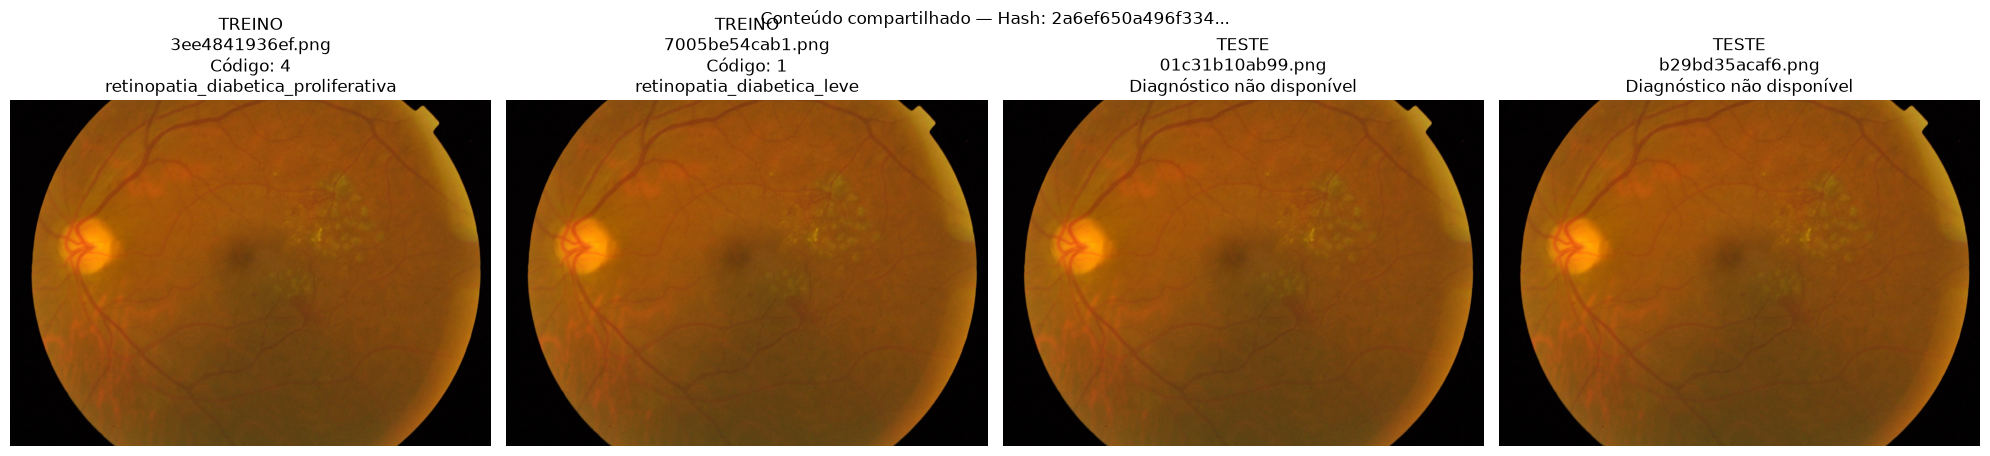

Hash completo: 2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d6e646047bb08878c81



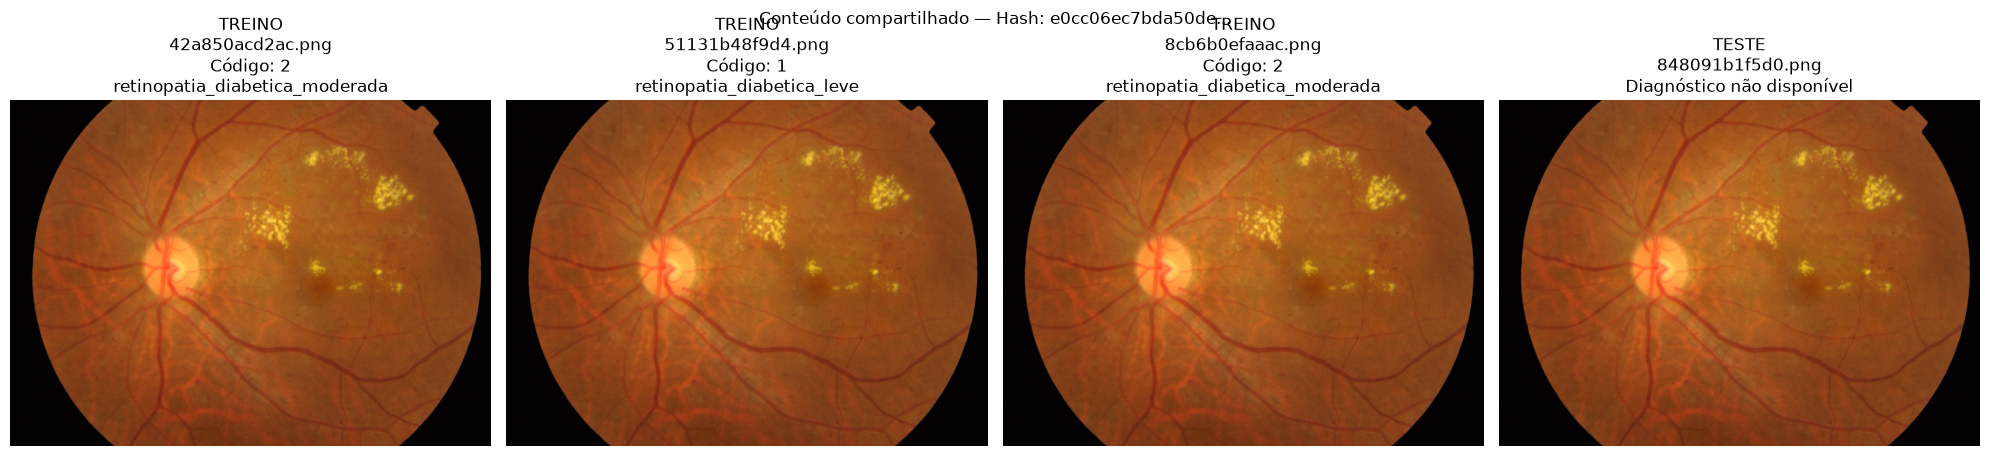

Hash completo: e0cc06ec7bda50ded0852785e77fb0f027161bffec4b7fa28712671e768e03b4



In [ ]:
# Exibe as imagens de treino e teste associadas aos hashes
# compartilhados que apresentam conflito de diagnóstico no treino.

APTOS_TRAIN_DIR = APTOS_DIR / "train_images"
APTOS_TEST_DIR = APTOS_DIR / "test_images"

for hash_atual in sorted(hashes_compartilhados_conflitantes_aptos):

    train_hash = casos_compartilhados_conflitantes_aptos[
        casos_compartilhados_conflitantes_aptos["hash"] == hash_atual
    ]

    test_hash = casos_test_conflitantes_aptos[
        casos_test_conflitantes_aptos["hash"] == hash_atual
    ]

    total_imagens = len(train_hash) + len(test_hash)

    fig, axes = plt.subplots(
        1,
        total_imagens,
        figsize=(5 * total_imagens, 5)
    )

    if total_imagens == 1:
        axes = [axes]

    indice = 0

    # Imagens do treino
    for _, linha in train_hash.iterrows():

        caminho = APTOS_TRAIN_DIR / linha["arquivo"]

        with Image.open(caminho) as img:
            axes[indice].imshow(img)

        axes[indice].set_title(
            f'TREINO\n'
            f'{linha["arquivo"]}\n'
            f'Código: {linha["codigo_diagnostico"]}\n'
            f'{linha["diagnostico"]}'
        )

        axes[indice].axis("off")
        indice += 1

    # Imagens do teste
    for _, linha in test_hash.iterrows():

        caminho = APTOS_TEST_DIR / linha["arquivo"]

        with Image.open(caminho) as img:
            axes[indice].imshow(img)

        axes[indice].set_title(
            f'TESTE\n'
            f'{linha["arquivo"]}\n'
            f'Diagnóstico não disponível'
        )

        axes[indice].axis("off")
        indice += 1

    plt.suptitle(
        f"Conteúdo compartilhado — Hash: {hash_atual[:16]}..."
    )

    plt.tight_layout()
    plt.show()

    print("Hash completo:", hash_atual)
    print()

##### Interpretação

A comparação entre os conjuntos de treino e teste identificou 140 hashes compartilhados, envolvendo 150 imagens do treino e 141 imagens do teste.

Entre esses conteúdos compartilhados, 2 hashes também pertencem a grupos que apresentam conflito de diagnóstico no conjunto de treinamento.

Esses casos envolvem 5 imagens do treino e 3 imagens do teste. Nas imagens de treino, o mesmo conteúdo aparece associado a diagnósticos diferentes. Já no conjunto de teste, os diagnósticos reais não estão disponíveis, portanto não é possível verificar se as classificações seriam consistentes.

A visualização dos casos confirma que existem imagens de conteúdo idêntico presentes nos dois conjuntos, o que representa um possível risco de vazamento de dados em experimentos que utilizem diretamente essa divisão entre treino e teste.

### 1.4 Resultados gerais do APTOS-2019

In [250]:
resumo_aptos = pd.DataFrame({
    "Característica": [
        "Quantidade de imagens",
        "Erros de leitura",
        "Formato",
        "Modo de cor",
        "Resoluções diferentes",
        "Resolução mais frequente",
        "Imagens na resolução mais frequente",
        "Tamanho médio dos arquivos (MB)",
        "Imagens em grupos duplicados",
        "Grupos de conteúdo duplicado",
        "Diagnósticos disponíveis"
    ],

    "Treino": [
        len(imagens_aptos_train),
        len(erros_aptos_train),
        ", ".join(analise_aptos_train["formato"].unique()),
        ", ".join(analise_aptos_train["modo_cor"].unique()),
        analise_aptos_train["resolucao"].nunique(),
        analise_aptos_train["resolucao"].value_counts().idxmax(),
        analise_aptos_train["resolucao"].value_counts().max(),
        round(analise_aptos_train["tamanho_mb"].mean(), 2),
        len(duplicados_aptos_train),
        duplicados_aptos_train["hash"].nunique(),
        "Sim"
    ],

    "Teste": [
        len(imagens_aptos_test),
        len(erros_aptos_test),
        ", ".join(analise_aptos_test["formato"].unique()),
        ", ".join(analise_aptos_test["modo_cor"].unique()),
        analise_aptos_test["resolucao"].nunique(),
        analise_aptos_test["resolucao"].value_counts().idxmax(),
        analise_aptos_test["resolucao"].value_counts().max(),
        round(analise_aptos_test["tamanho_mb"].mean(), 2),
        len(duplicados_aptos_test),
        duplicados_aptos_test["hash"].nunique(),
        "Não"
    ]
})

resumo_aptos

,Característica,Treino,Teste
0,Quantidade de imagens,3662,1928
1,Erros de leitura,0,0
2,Formato,PNG,PNG
3,Modo de cor,RGB,RGB
4,Resoluções diferentes,17,12
5,Resolução mais frequente,1050x1050,640x480
6,Imagens na resolução mais frequente,974,1403
7,Tamanho médio dos arquivos (MB),2.24,0.8
8,Imagens em grupos duplicados,251,12
9,Grupos de conteúdo duplicado,123,6


In [257]:
resumo_qualidade = pd.DataFrame({
    "Métrica": [
        "Grupos conflitantes no treino",
        "Imagens do treino em grupos conflitantes",
        "Hashes compartilhados entre treino e teste",
        "Imagens de treino envolvidas na sobreposição",
        "Imagens de teste envolvidas na sobreposição",
        "Hashes compartilhados com conflito no treino",
        "Imagens de treino nesses conflitos",
        "Imagens de teste correspondentes a esses conteúdos"
    ],

    "Resultado": [
        len(grupos_conflitantes_aptos),
        len(imagens_conflitantes_aptos),
        len(hashes_compartilhados_aptos),
        len(imagens_train_aptos_compartilhadas),
        len(imagens_test_aptos_compartilhadas),
        len(hashes_compartilhados_conflitantes_aptos),
        len(casos_compartilhados_conflitantes_aptos),
        len(casos_test_conflitantes_aptos)
    ]
})

resumo_qualidade

,Métrica,Resultado
0,Grupos conflitantes no treino,30
1,Imagens do treino em grupos conflitantes,62
2,Hashes compartilhados entre treino e teste,140
3,Imagens de treino envolvidas na sobreposição,150
4,Imagens de teste envolvidas na sobreposição,141
5,Hashes compartilhados com conflito no treino,2
6,Imagens de treino nesses conflitos,5
7,Imagens de teste correspondentes a esses conte...,3


### 1.5 Conclusão do APTOS-2019

A análise do APTOS-2019 mostrou que o dataset possui 5.590 imagens, sendo 3.662 pertencentes ao conjunto de treino e 1.928 ao conjunto de teste.

No conjunto de treino, os diagnósticos de Retinopatia Diabética estão distribuídos em cinco classes. Foi observado desbalanceamento entre essas classes, com predominância do grau 0, correspondente à ausência de retinopatia diabética, e menor representação do grau 3.

Todas as imagens analisadas estão no formato PNG e utilizam o modo de cor RGB. Não foram encontrados erros de leitura. Entretanto, foram identificadas diferentes resoluções nos dois conjuntos, demonstrando ausência de padronização das dimensões das imagens.

A análise de duplicatas por hash SHA-256 identificou 123 grupos de conteúdo duplicado no conjunto de treino, envolvendo 251 imagens. Entre esses grupos, 30 apresentam conflitos de diagnóstico, totalizando 62 imagens com conteúdo idêntico associado a classificações diferentes.

No conjunto de teste foram encontrados 6 grupos de conteúdo duplicado, envolvendo 12 imagens. Como os diagnósticos reais do conjunto de teste não estão disponíveis, não é possível avaliar conflitos de classificação nesse conjunto.

Também foi identificada sobreposição entre treino e teste, com 140 hashes compartilhados, envolvendo 150 imagens de treino e 141 imagens de teste. Entre esses conteúdos, 2 hashes pertencem a grupos que apresentam conflitos de diagnóstico no conjunto de treinamento, envolvendo 5 imagens de treino e 3 imagens de teste.

As visualizações realizadas confirmam tanto a presença de imagens duplicadas com classificações divergentes no conjunto de treino quanto a existência de conteúdos idênticos presentes simultaneamente nos conjuntos de treino e teste.

Esses resultados mostram que o APTOS-2019 apresenta características importantes que devem ser consideradas antes de sua utilização em experimentos, especialmente o desbalanceamento das classes, a variação das resoluções, a presença de duplicatas, os conflitos de classificação e a sobreposição entre treino e teste.

## 2. EyePACS

### 2.1 Conjunto de treino.

In [113]:
# Localizando o arquivo de metadados de treino do EyePACS.
EYEPACS_METADATA = (
    BASE_DIR 
    / "02.Catálogos" 
    / "METADADOS" 
    / "Treino" 
    / "eyepacs_metadata.csv"
)

print(EYEPACS_METADATA)
print("Existe:", EYEPACS_METADATA.exists())


C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Treino\eyepacs_metadata.csv
Existe: True


In [114]:
# Cria um dataframe a partir do arquivo CSV de metadados do EyePACS.
eyepacs = pd.read_csv(EYEPACS_METADATA)

# Mostra as primeiras linhas do dataframe.
eyepacs.head(6)

,numero_registro,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,10_left,EyePACS,10_left.jpeg,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
1,2,10_right,EyePACS,10_right.jpeg,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
2,3,13_left,EyePACS,13_left.jpeg,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
3,4,13_right,EyePACS,13_right.jpeg,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
4,5,15_left,EyePACS,15_left.jpeg,retinopatia_diabetica,1,retinopatia_diabetica_leve,train
5,6,15_right,EyePACS,15_right.jpeg,retinopatia_diabetica,2,retinopatia_diabetica_moderada,train


In [116]:
# Mostra as colunas do dataframe.
eyepacs.columns.tolist()

['numero_registro',
 'id_imagem',
 'dataset',
 'arquivo',
 'doenca',
 'codigo_diagnostico',
 'diagnostico',
 'conjunto']

#### 2.1.1 Estrutura geral do conjunto de treino.

In [118]:
print("Quantidade de registros:", len(eyepacs))
print("Quantidade de colunas:", len(eyepacs.columns))
print("Dimensão da tabela:", eyepacs.shape)

Quantidade de registros: 35126
Quantidade de colunas: 8
Dimensão da tabela: (35126, 8)


In [119]:
# Mostra a forma como a tabela está estruturada.
eyepacs.info()

<class 'pandas.DataFrame'>
RangeIndex: 35126 entries, 0 to 35125
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   numero_registro     35126 non-null  int64
 1   id_imagem           35126 non-null  str  
 2   dataset             35126 non-null  str  
 3   arquivo             35126 non-null  str  
 4   doenca              35126 non-null  str  
 5   codigo_diagnostico  35126 non-null  int64
 6   diagnostico         35126 non-null  str  
 7   conjunto            35126 non-null  str  
dtypes: int64(2), str(6)
memory usage: 2.1 MB


In [120]:
# Verifica se há valores nulos no dataframe.
eyepacs.isnull().sum()

numero_registro       0
id_imagem             0
dataset               0
arquivo               0
doenca                0
codigo_diagnostico    0
diagnostico           0
conjunto              0
dtype: int64

#### 2.1.2 Verificação de duplicatas e consistência dos registros.

In [121]:
# Verifica se há linhas duplicadas no conjunto de treino.
print("Linhas duplicadas:", eyepacs.duplicated().sum())
print("IDs duplicados:", eyepacs["id_imagem"].duplicated().sum())
print("Arquivos duplicados:", eyepacs["arquivo"].duplicated().sum())

Linhas duplicadas: 0
IDs duplicados: 0
Arquivos duplicados: 0


In [123]:
print("Valores da coluna dataset:") 
print(eyepacs["dataset"].value_counts())

print("\nValores da coluna doença:")
print(eyepacs["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(eyepacs["conjunto"].value_counts())

Valores da coluna dataset:
dataset
EyePACS    35126
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    35126
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
train    35126
Name: count, dtype: int64


### 2.1.3 Distribuição das classes.

In [125]:
# Mostra os códigos de diagnóstico e seus respectivos diagnósticos.
eyepacs[["codigo_diagnostico", "diagnostico"]].drop_duplicates().sort_values("codigo_diagnostico")


,codigo_diagnostico,diagnostico
0,0,sem_retinopatia_diabetica
4,1,retinopatia_diabetica_leve
5,2,retinopatia_diabetica_moderada
90,3,retinopatia_diabetica_grave
6,4,retinopatia_diabetica_proliferativa


In [126]:
# Checa a distribuição dos códigos de diagnóstico.
distribuicao = (
    eyepacs["codigo_diagnostico"].value_counts().sort_index()
)

distribuicao

codigo_diagnostico
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

In [127]:
percentual = (
    eyepacs["codigo_diagnostico"].value_counts(normalize=True).sort_index() * 100
)

percentual.round(2)

codigo_diagnostico
0    73.48
1     6.95
2    15.07
3     2.49
4     2.02
Name: proportion, dtype: float64

In [128]:
tabela_classes = pd.DataFrame({
    "Quantidade": distribuicao,
    "Percentual": percentual.round(2)
})

tabela_classes

,Quantidade,Percentual
codigo_diagnostico,,
0,25810,73.48
1,2443,6.95
2,5292,15.07
3,873,2.49
4,708,2.02


##### Interpretação

O conjunto de treino do EyePACS apresenta forte desbalanceamento entre as classes de diagnóstico.

A classe mais frequente é o grau 0, correspondente à ausência de retinopatia diabética, com 25.810 imagens, representando 73,48% do conjunto. Em seguida aparece o grau 2, com 5.292 imagens (15,07%).

As demais classes possuem participação bem menor: o grau 1 contém 2.443 imagens (6,95%), o grau 3 possui 873 imagens (2,49%) e o grau 4 apresenta 708 imagens (2,02%).

Assim, observa-se uma forte predominância de imagens sem retinopatia diabética e baixa representação dos casos mais graves, principalmente dos graus 3 e 4. Esse desbalanceamento deve ser considerado em futuras análises e experimentos com o dataset.

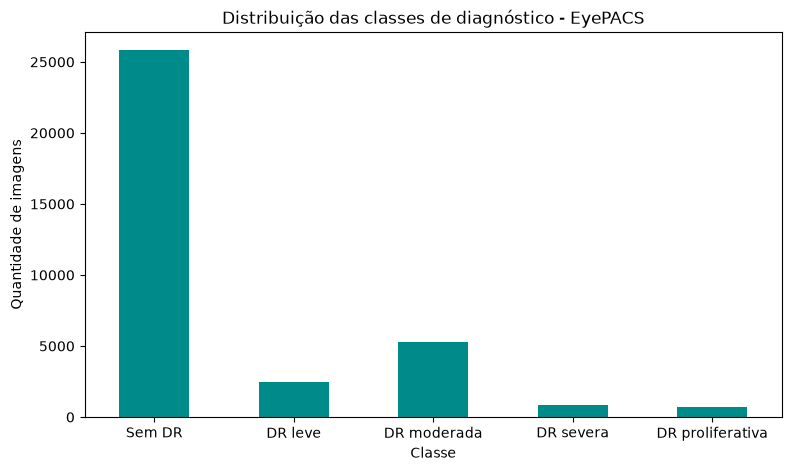

In [129]:
# Cria um gráfico para mostrar a distribuição das classes de diagnóstico com seus respectivos nomes.
nomes_classes = {
    0: "Sem DR",
    1: "DR leve",
    2: "DR moderada",
    3: "DR severa",
    4: "DR proliferativa"
}

quantidades = distribuicao.copy()
quantidades.index = quantidades.index.map(nomes_classes)

quantidades.plot(kind="bar", figsize=(9, 5), color="darkcyan")

plt.title("Distribuição das classes de diagnóstico - EyePACS")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=0)
plt.show()

#### 2.1.4 Correspodência entre metadata e imagens.

In [130]:
# Verifica se a pasta do EyePACS existe.
EYEPACS_DIR = (
    BASE_DIR
    / "01.Originais"
    / "DR (RETINOPATIA DIABÉTICA)"
    / "EyePACS"
)

print("Pasta do EyePACS:", EYEPACS_DIR)
print("Existe:", EYEPACS_DIR.exists())

Pasta do EyePACS: C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\01.Originais\DR (RETINOPATIA DIABÉTICA)\EyePACS
Existe: True


In [133]:
# Localiza as imagens de treino do EyePACS.

EYEPACS_TRAIN_IMAGES_DIR = EYEPACS_DIR / "train"

imagens_eyepacs_train = sorted(
    EYEPACS_TRAIN_IMAGES_DIR.glob("*.jpeg")
)

print("Quantidade de imagens de treino:", len(imagens_eyepacs_train))
print("Quantidade de registros no metadata:", len(eyepacs))

Quantidade de imagens de treino: 35126
Quantidade de registros no metadata: 35126


In [134]:
# Compara os arquivos de imagens de treino com os registros do metadados.
arquivos_metadata_train = set(eyepacs["arquivo"])
arquivos_imagens_train = set([imagem.name for imagem in imagens_eyepacs_train])

sem_imagem_train = arquivos_metadata_train - arquivos_imagens_train
sem_metadata_train = arquivos_imagens_train - arquivos_metadata_train

print("Arquivos no metadados sem imagem correspondente:", len(sem_imagem_train))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata_train))

Arquivos no metadados sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 2.1.5 Análise técnica das imagens de treino.

In [147]:
# Analisa uma imagem de treino para verificar seu formato e modo de cor.
from PIL import Image

imagem_exemplo_eyepacs = imagens_eyepacs_train[0]

with Image.open(imagem_exemplo_eyepacs) as img:
    print("Arquivo:", imagem_exemplo_eyepacs.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 10003_left.jpeg
Formato: JPEG
Modo de cor: RGB
Resolução: (4752, 3168)


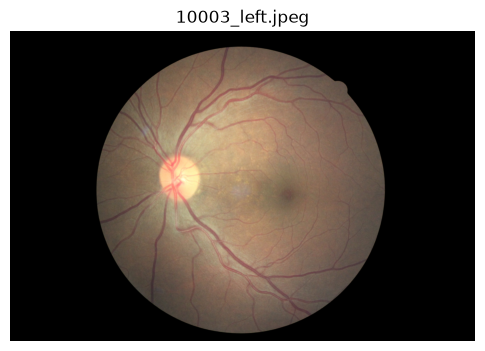

In [148]:
# Mostra a imagem de exemplo.
with Image.open(imagem_exemplo_eyepacs) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo_eyepacs.name)
    plt.show()

In [149]:
# Função para analisar tecnicamente o conjunto de imagens.
def analisar_imagens(lista_imagens):
    registros = []
    erros = []

    for caminho in lista_imagens:
        try:
            with Image.open(caminho) as img:

                # Força a leitura da imagem inteira.
                img.load()

                registros.append({
                    "arquivo": caminho.name,
                    "formato": img.format,
                    "modo_cor": img.mode,
                    "largura": img.width,
                    "altura": img.height,
                    "resolucao": f"{img.width}x{img.height}",
                    "tamanho_mb": caminho.stat().st_size / (1024 ** 2)
                })

        except Exception as erro:
            erros.append({
                "arquivo": caminho.name,
                "erro": str(erro)
            })

    dados = pd.DataFrame(registros)
    erros = pd.DataFrame(erros)

    return dados, erros

In [153]:
# Analisa todas as imagens de treino.
analise_eyepacs_train, erros_eyepacs_train = analisar_imagens(imagens_eyepacs_train)

print("Imagens analisadas:", len(analise_eyepacs_train))
print("Erros de leitura:", len(erros_eyepacs_train))

analise_eyepacs_train.head()

Imagens analisadas: 35126
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,10003_left.jpeg,JPEG,RGB,4752,3168,4752x3168,1.490659
1,10003_right.jpeg,JPEG,RGB,4752,3168,4752x3168,1.510454
2,10007_left.jpeg,JPEG,RGB,3456,2304,3456x2304,0.785137
3,10007_right.jpeg,JPEG,RGB,3456,2304,3456x2304,0.822745
4,10009_left.jpeg,JPEG,RGB,3888,2592,3888x2592,1.471003


In [154]:
# Mostra formatos e modos de cor encontrados nas imagens de treino.
print("Fomatos encontrados:")
print(analise_eyepacs_train["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_eyepacs_train["modo_cor"].value_counts())

Fomatos encontrados:
formato
JPEG    35126
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    35126
Name: count, dtype: int64


In [155]:
print("Quantidade de resoluções diferentes:")
print(analise_eyepacs_train["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_eyepacs_train["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
29

10 resoluções mais frequentes:
resolucao
3888x2592    10352
4752x3168     5550
3504x2336     4144
2560x1920     3858
2592x1944     3795
3456x2304     1628
4928x3264     1558
4272x2848      854
3008x2000      836
2816x1880      508
Name: count, dtype: int64


In [158]:
print("Estatísticas da largura:")
print(analise_eyepacs_train["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_eyepacs_train["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_eyepacs_train["tamanho_mb"].describe())

Estatísticas da largura:
count    35126.000000
mean      3636.655241
std        801.830170
min        400.000000
25%       2816.000000
50%       3888.000000
75%       3888.000000
max       5184.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    35126.000000
mean      2473.033166
std        471.474465
min        289.000000
25%       1944.000000
50%       2592.000000
75%       2592.000000
max       3456.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    35126.000000
mean         1.030189
std          0.400861
min          0.007872
25%          0.721072
50%          1.109891
75%          1.364874
max          2.068991
Name: tamanho_mb, dtype: float64


##### Interpretação

As 35.126 imagens do conjunto de treino do EyePACS foram analisadas quanto às suas dimensões e ao tamanho dos arquivos.

A largura das imagens varia entre 400 e 5.184 pixels, com média de aproximadamente 3.637 pixels e mediana de 3.888 pixels. A altura varia entre 289 e 3.456 pixels, apresentando média de aproximadamente 2.473 pixels e mediana de 2.592 pixels.

Esses valores mostram que o conjunto apresenta variação considerável nas dimensões das imagens. Também existem arquivos com dimensões muito inferiores às predominantes no dataset, como demonstrado pelos valores mínimos de 400 pixels de largura e 289 pixels de altura, o que merece atenção em futuras etapas de pré-processamento.

O tamanho dos arquivos varia aproximadamente entre 0,008 MB e 2,07 MB, com média de 1,03 MB e mediana de 1,11 MB. A maior parte dos arquivos encontra-se entre aproximadamente 0,72 MB e 1,36 MB.

Portanto, o EyePACS apresenta heterogeneidade tanto nas dimensões quanto no tamanho dos arquivos. Essas diferenças devem ser consideradas em futuras etapas de preparação dos dados, especialmente caso as imagens sejam utilizadas como entrada de modelos que exijam dimensões padronizadas.

#### 2.1.6 Qualidade e duplicatas das imagens.

In [168]:
# Cria um dataframe com os hashes das imagens de treino.
hashes_eyepacs_train = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_eyepacs_train],
    "hash": [calcular_hash(imagem) for imagem in imagens_eyepacs_train]
})

hashes_eyepacs_train.head()

,arquivo,hash
0,10003_left.jpeg,9f1bea63d975899522b8bfeaaaa2a2832bb342a15886d9...
1,10003_right.jpeg,aa7f6ce2550c9825db18d3adf9e87bfa2af6715804f6e8...
2,10007_left.jpeg,baf35e99be23002a69d8acdb7287e847ed21e3dfc22380...
3,10007_right.jpeg,cffba76236c28a673e0b487fdd4155900794493fb9f4a3...
4,10009_left.jpeg,c4392f3a6a2e608895beaf26f60fca26ab6a2d4a40f133...


In [170]:
# Identifica imagens duplicadas em treino com base no hash.
duplicados_eyepacs_train = hashes_eyepacs_train[
    hashes_eyepacs_train["hash"].duplicated(keep=False)
].sort_values("hash")

print("Imagens pertencentes a grupos duplicados:", len(duplicados_eyepacs_train))
print("Hashes duplicados:", duplicados_eyepacs_train["hash"].nunique())

Imagens pertencentes a grupos duplicados: 0
Hashes duplicados: 0


In [174]:
# Relaciona os hashes das imagens aos diagnósticos do conjunto de treino.

hashes_train_diagnostico_eyepacs = hashes_eyepacs_train.merge(
    eyepacs[["arquivo", "codigo_diagnostico", "diagnostico"]],
    on="arquivo",
    how="left"
)

# Conta quantos diagnósticos diferentes existem para cada hash.

diagnosticos_por_hash = (
    hashes_train_diagnostico_eyepacs
    .groupby("hash")["codigo_diagnostico"]
    .nunique()
)

# Seleciona hashes associados a diagnósticos diferentes.

grupos_conflitantes = diagnosticos_por_hash[
    diagnosticos_por_hash > 1
]

# Identifica todas as imagens desses grupos.

imagens_conflitantes = hashes_train_diagnostico_eyepacs[
    hashes_train_diagnostico_eyepacs["hash"].isin(grupos_conflitantes.index)
]

print("Grupos conflitantes:", len(grupos_conflitantes))
print("Imagens envolvidas:", len(imagens_conflitantes))

Grupos conflitantes: 0
Imagens envolvidas: 0


### 2.2 Conjunto de teste.

#### 2.2.1 Estrutura do conjunto de teste.

In [189]:
# Localizando o arquivo de metadados de teste do EYEPACS.
EYEPACS_TEST_METADATA = (
    BASE_DIR
    / "02.Catálogos"
    / "METADADOS"
    / "Teste"
    / "eyepacs_test_metadata.csv"
)

print(EYEPACS_TEST_METADATA)
print("Existe:", EYEPACS_TEST_METADATA.exists())

C:\Users\d4rki\Desktop\Pesquisa\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Teste\eyepacs_test_metadata.csv
Existe: True


In [190]:
# Cria o dataframe de a partir dos metadados de teste do EyePACS.
eyepacs_test = pd.read_csv(EYEPACS_TEST_METADATA)

eyepacs_test.head()

,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,EyePACS,10000_left.jpeg,retinopatia_diabetica,NaN,nao_disponivel,test
1,2,EyePACS,10000_right.jpeg,retinopatia_diabetica,NaN,nao_disponivel,test
2,3,EyePACS,10001_left.jpeg,retinopatia_diabetica,NaN,nao_disponivel,test
3,4,EyePACS,10001_right.jpeg,retinopatia_diabetica,NaN,nao_disponivel,test
4,5,EyePACS,10002_left.jpeg,retinopatia_diabetica,NaN,nao_disponivel,test


In [191]:
print("Quantidade de registros:", len(eyepacs_test))
print("Quantidade de colunas:", len(eyepacs_test.columns))
print("Dimensão da tabela:", eyepacs_test.shape)

Quantidade de registros: 53576
Quantidade de colunas: 7
Dimensão da tabela: (53576, 7)


In [193]:
# Mostra a estrutura do dataframe de teste.
eyepacs_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 53576 entries, 0 to 53575
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_imagem           53576 non-null  int64  
 1   dataset             53576 non-null  str    
 2   arquivo             53576 non-null  str    
 3   doenca              53576 non-null  str    
 4   codigo_diagnostico  0 non-null      float64
 5   diagnostico         53576 non-null  str    
 6   conjunto            53576 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 2.9 MB


In [194]:
# Verifica valores ausentes no conjunto de teste.
eyepacs_test.isnull().sum()

id_imagem                 0
dataset                   0
arquivo                   0
doenca                    0
codigo_diagnostico    53576
diagnostico               0
conjunto                  0
dtype: int64

#### 2.2.2 Verificação de duplicatas e consistência dos registros.

In [195]:
# Checa se há linhas duplicadas no conjunto de teste.
print("Linhas duplicadas no conjunto de teste:", eyepacs_test.duplicated().sum())
print("IDs duplicados no conjunto de teste:", eyepacs_test["id_imagem"].duplicated().sum())
print("Arquivos duplicados no conjunto de teste:", eyepacs_test["arquivo"].duplicated().sum())

Linhas duplicadas no conjunto de teste: 0
IDs duplicados no conjunto de teste: 0
Arquivos duplicados no conjunto de teste: 0


In [196]:
print("Valores da coluna dataset:")
print(eyepacs_test["dataset"].value_counts())

print("\nValores da coluna doença:")
print(eyepacs_test["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(eyepacs_test["conjunto"].value_counts())

print("\nCódigos de diagnóstico ausentes:")
print(eyepacs_test["codigo_diagnostico"].isna().sum())

Valores da coluna dataset:
dataset
EyePACS    53576
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    53576
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
test    53576
Name: count, dtype: int64

Códigos de diagnóstico ausentes:
53576


#### 2.2.3 Disponibilidade dos diagnósticos.

In [197]:
# Verifica a disponibilidade dos diagnósticos no conjunto de teste.

print(
    "Códigos de diagnóstico ausentes:",
    eyepacs_test["codigo_diagnostico"].isna().sum()
)

print("\nValores da coluna diagnóstico:")
print(
    eyepacs_test["diagnostico"].value_counts(dropna=False)
)

Códigos de diagnóstico ausentes: 53576

Valores da coluna diagnóstico:
diagnostico
nao_disponivel    53576
Name: count, dtype: int64


##### Interpretação

O conjunto de teste do EyePACS possui 53.576 registros no metadata criado para esta análise.

Os 53.576 registros apresentam ausência de valores na coluna `codigo_diagnostico`, enquanto a coluna `diagnostico` foi preenchida com `nao_disponivel`.

Isso ocorre porque os diagnósticos reais das imagens do conjunto de teste não estão disponíveis nos arquivos utilizados nesta análise. Portanto, não é possível calcular a distribuição das classes, comparar a frequência dos diferentes graus de retinopatia diabética ou verificar possíveis conflitos de classificação nesse conjunto.

O metadata criado tem finalidade organizacional e técnica, permitindo relacionar cada arquivo de imagem ao dataset, à doença analisada e ao conjunto de teste, sem atribuir rótulos diagnósticos que não estão disponíveis.

#### 2.2.4 Correspondência entre metadata e imagens.

In [213]:
# Localiza as imagens do conjunto de teste do EyePACS.

EYEPACS_TEST_IMAGES_DIR = EYEPACS_DIR / "test"

imagens_eyepacs_test = sorted(EYEPACS_TEST_IMAGES_DIR.glob("*.jpeg"))

print("Quantidade de imagens de teste:", len(imagens_eyepacs_test))

print("Quantidade de registros no metadata:", len(eyepacs_test))

Quantidade de imagens de teste: 53576
Quantidade de registros no metadata: 53576


In [212]:
# Compara os arquivos do metadata com as imagens de teste.
arquivos_sem_metadata_eyepacs_test = set(eyepacs_test["arquivo"])
arquivos_sem_imagem_eyepacs_test = set(imagem.name for imagem in imagens_eyepacs_test)

sem_imagem_eyepacs_test = (arquivos_sem_metadata_eyepacs_test - arquivos_sem_imagem_eyepacs_test)
sem_metadata_eyepacs_test = (arquivos_sem_imagem_eyepacs_test - arquivos_sem_metadata_eyepacs_test)

print("Arquivos no metadata sem imagem correspondente:", len(sem_imagem_eyepacs_test))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata_eyepacs_test))

Arquivos no metadata sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 2.2.5 Análise técnica das imagens de teste.

In [218]:
# Analisa uma imagem de teste para verificar seu formato e modo de cor.
imagem_exemplo_eyepacs_test = imagens_eyepacs_test[0]

with Image.open(imagem_exemplo_eyepacs_test) as img:
    print("Arquivo:", imagem_exemplo_eyepacs_test.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 10000_left.jpeg
Formato: JPEG
Modo de cor: RGB
Resolução: (3264, 2448)


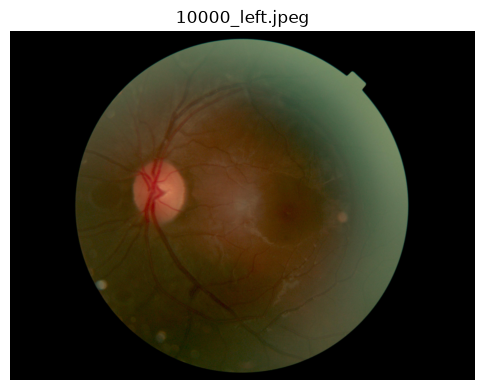

In [220]:
# Mostra a imagem de teste.
with Image.open(imagem_exemplo_eyepacs_test) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo_eyepacs_test.name)
    plt.show()

In [222]:
# Reutiliza a função de análise para o conjunto de imagens de teste.
analise_eyepacs_test, erros_eyepacs_test = analisar_imagens(imagens_eyepacs_test)

print("Imagens analisadas:", len(analise_eyepacs_test))
print("Erros de leitura:", len(erros_eyepacs_test))

analise_eyepacs_test.head()

Imagens analisadas: 53576
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,10000_left.jpeg,JPEG,RGB,3264,2448,3264x2448,0.539926
1,10000_right.jpeg,JPEG,RGB,3264,2448,3264x2448,0.495375
2,10001_left.jpeg,JPEG,RGB,4752,3168,4752x3168,1.659566
3,10001_right.jpeg,JPEG,RGB,4752,3168,4752x3168,1.648299
4,10002_left.jpeg,JPEG,RGB,2592,1944,2592x1944,0.386174


In [223]:
# Mostra formatos e modos de cor encontrados nas imagens de teste.
print("Formatos encontrados:")
print(analise_eyepacs_test["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_eyepacs_test["modo_cor"].value_counts())

Formatos encontrados:
formato
JPEG    53576
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    53576
Name: count, dtype: int64


In [224]:
# Mostra estatísticas das resoluções encontradas nas imagens de teste.
print("Quantidade de resoluções diferentes:")
print(analise_eyepacs_test["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_eyepacs_test["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
31

10 resoluções mais frequentes:
resolucao
3888x2592    15518
4752x3168     8518
3504x2336     6478
2560x1920     6129
2592x1944     6071
3456x2304     2398
4928x3264     2246
4272x2848     1264
3008x2000     1222
2816x1880      712
Name: count, dtype: int64


In [225]:
print("Estatísticas da largura:")
print(analise_eyepacs_test["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_eyepacs_test["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_eyepacs_test["tamanho_mb"].describe())

Estatísticas da largura:
count    53576.000000
mean      3625.979282
std        802.563768
min        320.000000
25%       2816.000000
50%       3888.000000
75%       3888.000000
max       5184.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    53576.000000
mean      2468.050060
std        470.031129
min        211.000000
25%       1944.000000
50%       2592.000000
75%       2592.000000
max       3456.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    53576.000000
mean         1.028250
std          0.402489
min          0.007414
25%          0.720340
50%          1.107760
75%          1.364997
max          2.135144
Name: tamanho_mb, dtype: float64


##### Interpretação

As estatísticas foram calculadas para as 53.576 imagens do conjunto de teste do EyePACS.

A largura das imagens varia entre 320 e 5.184 pixels, com média de aproximadamente 3.626 pixels e mediana de 3.888 pixels. A altura também apresenta variação considerável, com valor mínimo de 211 pixels e média de aproximadamente 2.468 pixels.

A maior parte das imagens possui dimensões significativamente maiores que os valores mínimos observados. Por exemplo, 75% das imagens apresentam largura de até 3.888 pixels, enquanto algumas imagens possuem apenas algumas centenas de pixels de largura e altura.

Esses resultados demonstram que o conjunto de teste, assim como o conjunto de treino, não possui dimensões totalmente padronizadas. A presença de imagens com resoluções muito inferiores às predominantes deve ser considerada em futuras etapas de pré-processamento, especialmente em aplicações que exijam redimensionamento ou padronização da entrada.

De modo geral, o conjunto de teste apresenta grande quantidade de imagens e heterogeneidade nas dimensões, característica importante para a preparação e utilização do EyePACS em experimentos posteriores.

#### 2.2.6 Qualidade e duplicatas das imagens.

In [228]:
# Calcula o hash de todas as imagens de teste.

hashes_eyepacs_test = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_eyepacs_test],
    "hash": [calcular_hash(imagem) for imagem in imagens_eyepacs_test]
})

hashes_eyepacs_test.head()

,arquivo,hash
0,10000_left.jpeg,d33a843f13273b32fd8b8fc473f417442a5687f51aaba4...
1,10000_right.jpeg,1c12982f9061b32a50ceb6e45b52c1faf7d68b81cb9a97...
2,10001_left.jpeg,584d08728d67b149c7dfda170de58e18df264cba5a3f41...
3,10001_right.jpeg,2cbeceba709016e4855a6da5fde1f4ae901984514ff01f...
4,10002_left.jpeg,4f00e07c4a25b52a0dfdebf0ce30f9c44607882cb2556f...


In [229]:
# Identifica imagens duplicadas no teste com base no hash.

duplicados_eyepacs_test = hashes_eyepacs_test[
    hashes_eyepacs_test["hash"].duplicated(keep=False)
].sort_values("hash")

print(
    "Imagens pertencentes a grupos duplicados:",
    len(duplicados_eyepacs_test)
)

print(
    "Hashes duplicados:",
    duplicados_eyepacs_test["hash"].nunique()
)

Imagens pertencentes a grupos duplicados: 0
Hashes duplicados: 0


### 2.3 Comparação entre treino e teste

#### 2.3.1 Duplicatas entre os conjuntos

In [237]:
# Identifica hashes presentes tanto no conjunto de treino quanto no conjunto de teste.

hashes_compartilhados_eyepacs = (
    set(hashes_eyepacs_train["hash"])
    & set(hashes_eyepacs_test["hash"])
)

print(
    "Hashes compartilhados entre treino e teste:",
    len(hashes_compartilhados_eyepacs)
)

Hashes compartilhados entre treino e teste: 0


In [240]:
# Localiza as imagens de treino e teste que possuem
# hashes presentes nos dois conjuntos.

imagens_train_eyepacs_compartilhadas = hashes_eyepacs_train[
    hashes_eyepacs_train["hash"].isin(hashes_compartilhados_eyepacs)
]

imagens_test_eyepacs_compartilhadas = hashes_eyepacs_test[
    hashes_eyepacs_test["hash"].isin(hashes_compartilhados_eyepacs)
]

print(
    "Imagens de treino envolvidas:",
    len(imagens_train_eyepacs_compartilhadas)
)

print(
    "Imagens de teste envolvidas:",
    len(imagens_test_eyepacs_compartilhadas)
)

Imagens de treino envolvidas: 0
Imagens de teste envolvidas: 0


### 2.4 Resultados gerais do APTOS-2019

In [258]:
resumo_eyepacs = pd.DataFrame({
    "Característica": [
        "Quantidade de imagens",
        "Erros de leitura",
        "Formato",
        "Modo de cor",
        "Resoluções diferentes",
        "Resolução mais frequente",
        "Imagens na resolução mais frequente",
        "Tamanho médio dos arquivos (MB)",
        "Imagens em grupos duplicados",
        "Grupos de conteúdo duplicado",
        "Diagnósticos disponíveis"
    ],

    "Treino": [
        len(imagens_eyepacs_train),
        len(erros_eyepacs_train),
        ", ".join(analise_eyepacs_train["formato"].unique()),
        ", ".join(analise_eyepacs_train["modo_cor"].unique()),
        analise_eyepacs_train["resolucao"].nunique(),
        analise_eyepacs_train["resolucao"].value_counts().idxmax(),
        analise_eyepacs_train["resolucao"].value_counts().max(),
        round(analise_eyepacs_train["tamanho_mb"].mean(), 2),
        len(duplicados_eyepacs_train),
        duplicados_eyepacs_train["hash"].nunique(),
        "Sim"
    ],

    "Teste": [
        len(imagens_eyepacs_test),
        len(erros_eyepacs_test),
        ", ".join(analise_eyepacs_test["formato"].unique()),
        ", ".join(analise_eyepacs_test["modo_cor"].unique()),
        analise_eyepacs_test["resolucao"].nunique(),
        analise_eyepacs_test["resolucao"].value_counts().idxmax(),
        analise_eyepacs_test["resolucao"].value_counts().max(),
        round(analise_eyepacs_test["tamanho_mb"].mean(), 2),
        len(duplicados_eyepacs_test),
        duplicados_eyepacs_test["hash"].nunique(),
        "Não"
    ]
})

resumo_eyepacs

,Característica,Treino,Teste
0,Quantidade de imagens,35126,53576
1,Erros de leitura,0,0
2,Formato,JPEG,JPEG
3,Modo de cor,RGB,RGB
4,Resoluções diferentes,29,31
5,Resolução mais frequente,3888x2592,3888x2592
6,Imagens na resolução mais frequente,10352,15518
7,Tamanho médio dos arquivos (MB),1.03,1.03
8,Imagens em grupos duplicados,0,0
9,Grupos de conteúdo duplicado,0,0


In [259]:
resumo_qualidade_eyepacs = pd.DataFrame({
    "Métrica": [
        "Imagens duplicadas no treino",
        "Grupos de conteúdo duplicado no treino",
        "Imagens duplicadas no teste",
        "Grupos de conteúdo duplicado no teste",
        "Hashes compartilhados entre treino e teste",
        "Imagens de treino envolvidas na sobreposição",
        "Imagens de teste envolvidas na sobreposição",
        "Grupos conflitantes no treino"
    ],

    "Resultado": [
        len(duplicados_eyepacs_train),
        duplicados_eyepacs_train["hash"].nunique(),
        len(duplicados_eyepacs_test),
        duplicados_eyepacs_test["hash"].nunique(),
        len(hashes_compartilhados_eyepacs),
        len(imagens_train_eyepacs_compartilhadas),
        len(imagens_test_eyepacs_compartilhadas),
        0
    ]
})

resumo_qualidade_eyepacs

,Métrica,Resultado
0,Imagens duplicadas no treino,0
1,Grupos de conteúdo duplicado no treino,0
2,Imagens duplicadas no teste,0
3,Grupos de conteúdo duplicado no teste,0
4,Hashes compartilhados entre treino e teste,0
5,Imagens de treino envolvidas na sobreposição,0
6,Imagens de teste envolvidas na sobreposição,0
7,Grupos conflitantes no treino,0


### 2.5 Comclusão do EyePACS

### 2.5 Conclusão do EyePACS

A análise do EyePACS considerou 88.702 imagens, sendo 35.126 pertencentes ao conjunto de treino e 53.576 ao conjunto de teste.

No conjunto de treino, os diagnósticos de retinopatia diabética estão distribuídos em cinco classes. Foi observado forte desbalanceamento, com predominância do grau 0, correspondente à ausência de retinopatia diabética, com 25.810 imagens (73,48%). As classes referentes aos graus mais avançados apresentam menor representação, especialmente os graus 3 e 4.

As imagens analisadas estão no formato JPEG e utilizam o modo de cor RGB. As análises técnicas também evidenciaram variação considerável nas dimensões das imagens. No treino, foram encontradas larguras entre 400 e 5.184 pixels e alturas entre 289 e 3.456 pixels. No teste, foram observadas imagens ainda menores, com largura mínima de 320 pixels e altura mínima de 211 pixels.

O conjunto de teste não possui diagnósticos reais disponíveis nos arquivos utilizados nesta análise. Por esse motivo, foi criado um metadata técnico contendo os 53.576 arquivos, mantendo o código de diagnóstico ausente e identificando o diagnóstico como `nao_disponivel`.

A análise de duplicatas utilizando hash SHA-256 não identificou imagens exatamente duplicadas dentro do conjunto de treino nem dentro do conjunto de teste. Também não foram encontrados hashes compartilhados entre os dois conjuntos.

Dessa forma, diferentemente do observado no APTOS-2019, não foram identificados conteúdos exatamente duplicados, conflitos de diagnóstico associados a duplicatas ou sobreposição exata entre treino e teste no EyePACS.

Os principais aspectos observados no EyePACS são o elevado número de imagens, o forte desbalanceamento das classes do conjunto de treino, a heterogeneidade das dimensões e a ausência de diagnósticos no conjunto de teste. Essas características devem ser consideradas em futuras etapas de pré-processamento e utilização do dataset em experimentos.